# High Dynamic Range (HDR) Imaging

**Satya Mallick, LearnOpenCV.com**

!["HDR Image Example"](https://learnopencv.com/wp-content/uploads/2023/03/opencv_bootcamp_10_high-dynamic-range-hdr.jpg)

In [1]:
# Import Libraries
import os
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve


%matplotlib inline

##  <font style="color:black">Download Assets</font>

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/qa1hsyxt66pvj02/opencv_bootcamp_assets_NB10.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB10.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Basic Idea

1. The **dynamic range** of images is limited to 8-bits (0 - 255) per channel
2. Very bright pixels saturate to 255
3. Very dark pixels clip to 0

# Step 1: Capture Multiple Exposures

!["HDR Image Sequence"](https://learnopencv.com/wp-content/uploads/2023/03/opencv_bootcamp_10_hdr-image-sequence.jpg)

In [4]:
def readImagesAndTimes():
    # List of file names
    # filenames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]
    filenames = ["images/hdr/IMG_20250627_231023_-1.jpg",
                 "images/hdr/IMG_20250627_231023_0.jpg",
                 "images/hdr/IMG_20250627_231023_1.jpg",
                 ]

    # List of exposure times
    # times = np.array([1 / 30.0, 0.25, 2.5, 15.0], dtype=np.float32)
    times = np.array([0.120016,0.20002,0.20002], dtype=np.float32)

    # Read images
    images = []
    for filename in filenames:
        im = cv2.imread(filename)
        # im = cv2.imread("/home/hmoya/PycharmProjects/OpenCV/images/hdr/"+filename)
        images.append(im)

    return images, times

# Step 2: Align Images

![Aligned vs. Unaligned](https://learnopencv.com/wp-content/uploads/2023/03/opencv_bootcamp_10_aligned-unaligned-hdr-comparison.jpg)

In [5]:
# Read images and exposure times
images, times = readImagesAndTimes()

In [6]:
# ims2=images

# Align Images
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)
# pts_a = cv2.findNonZero(ims2)
# pts_b = cv2.findNonZero(images)
#
# hd = cv2.createHausdorffDistanceExtractor()
#
# d1 = hd.computeDistance(pts_a, pts_b)
#
# # print(d1)
# if d1 is None:
#     print("All images are equal")

# Step 3: Estimate Camera Response Function

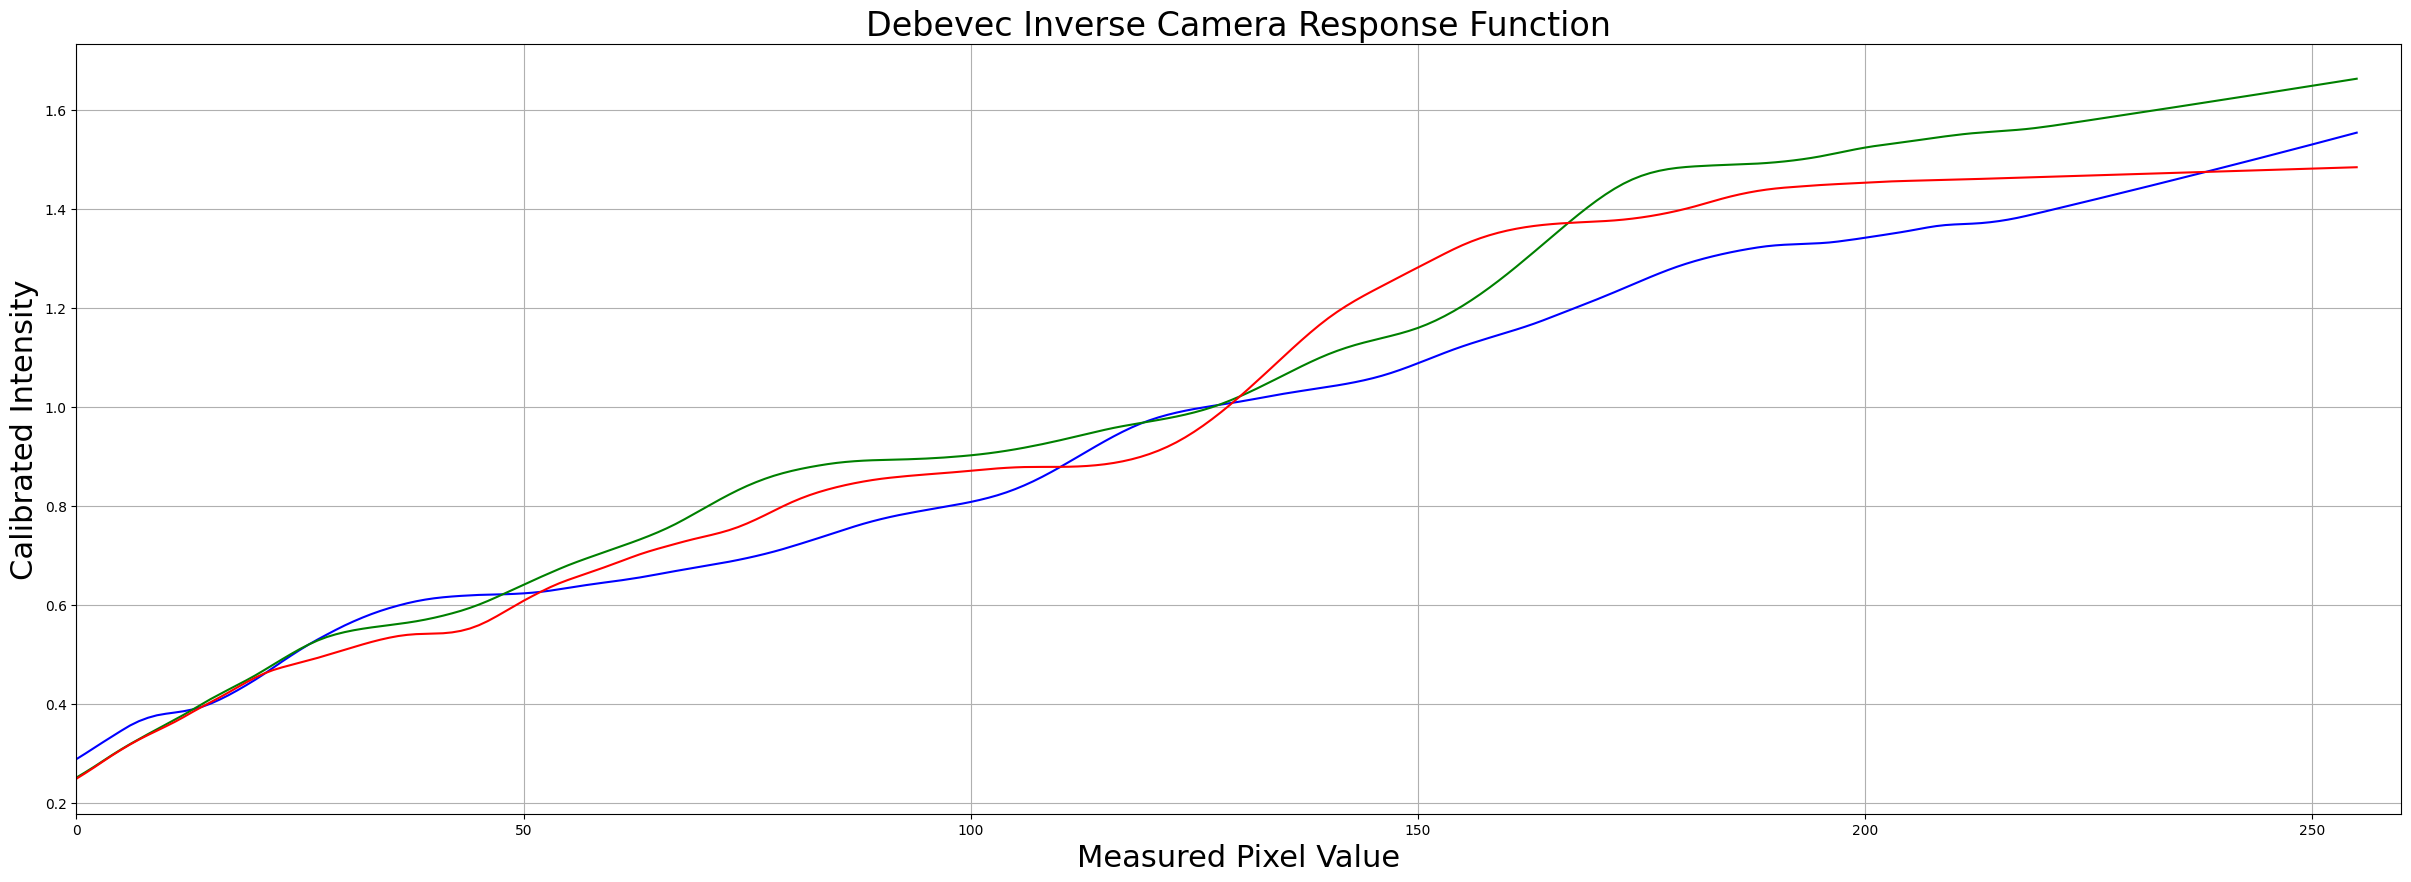

In [7]:
# Find Camera Response Function (CRF)
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

# Plot CRF
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=(30, 10))
plt.title("Debevec Inverse Camera Response Function", fontsize=24)
plt.xlabel("Measured Pixel Value", fontsize=22)
plt.ylabel("Calibrated Intensity", fontsize=22)
plt.xlim([0, 260])
plt.grid()
plt.plot(x, y[:, 0], "b", x, y[:, 1], "g", x, y[:, 2], "r")

# Step 4: Merge Exposure into an HDR Image

In [8]:
# Merge images into an HDR linear image
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

# Step 5: Tonemapping

Many Tonemapping algorithms are available in OpenCV. We chose Drago as it has more controls.

[ WARN:0@2.780] global matrix_expressions.cpp:1333 assign OpenCV/MatExpr: processing of multi-channel arrays might be changed in the future: https://github.com/opencv/opencv/issues/16739
[ WARN:0@3.249] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


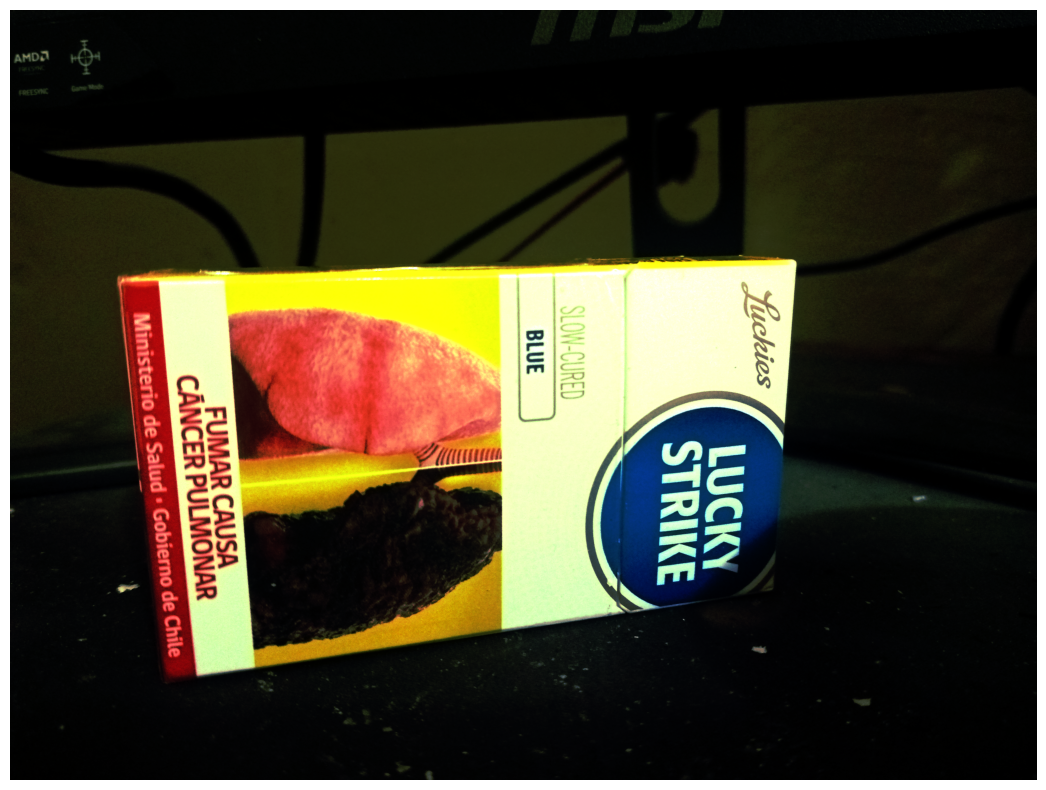

In [9]:
# Tonemap using Drago's method to obtain 24-bit color image
# createTonemapDrago(gamma: float = ...,
#                    saturation: float = ...,
#                    bias: float = ...)
# tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
tonemapDrago = cv2.createTonemapDrago(0.2, 0.5,0.85)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago

# Saving image
cv2.imwrite("ldr-Drago.jpg", 255*ldrDrago)

# Plotting image
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrDrago, 0, 1)[:,:,::-1]);plt.axis("off");
# plt.figure(figsize=(20, 10));plt.imshow(ldrDrago[:,:,::-1]);plt.axis("off");

Tonemaping using Reinhard's method ... 


(np.float64(-0.5), np.float64(4031.5), np.float64(3023.5), np.float64(-0.5))

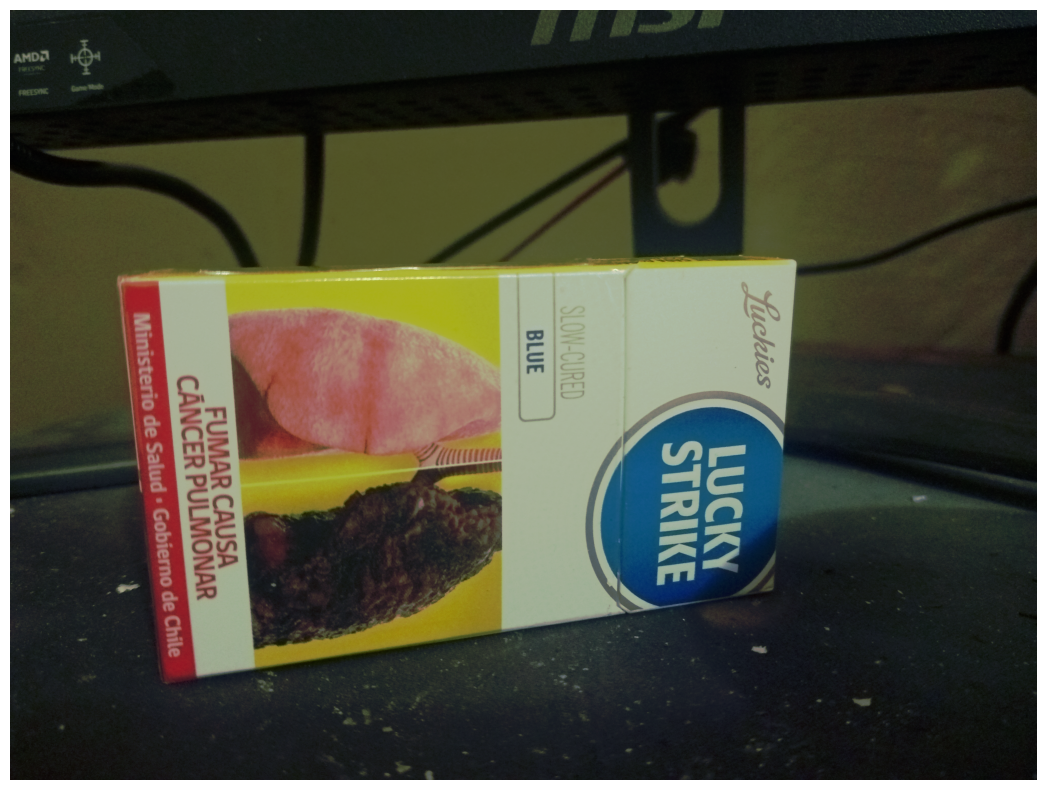

In [10]:
# Tonemap using Reinhard's method to obtain 24-bit color image
#  createTonemapReinhard(gamma: float = ...,
#                       intensity: float = ...,
#                       light_adapt: float = ...,
#                       color_adapt: float = ...)
print("Tonemaping using Reinhard's method ... ")
# tonemapReinhard = cv2.createTonemapReinhard(1.5, 0, 0, 0)
tonemapReinhard = cv2.createTonemapReinhard(0.5, 0, 0, 0)
ldrReinhard = tonemapReinhard.process(hdrDebevec)

# Saving image
cv2.imwrite("ldr-Reinhard.jpg", ldrReinhard * 255)

# Plotting image
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrReinhard, 0, 1)[:,:,::-1]);plt.axis("off")

Tonemaping using Mantiuk's method ... 


(np.float64(-0.5), np.float64(4031.5), np.float64(3023.5), np.float64(-0.5))

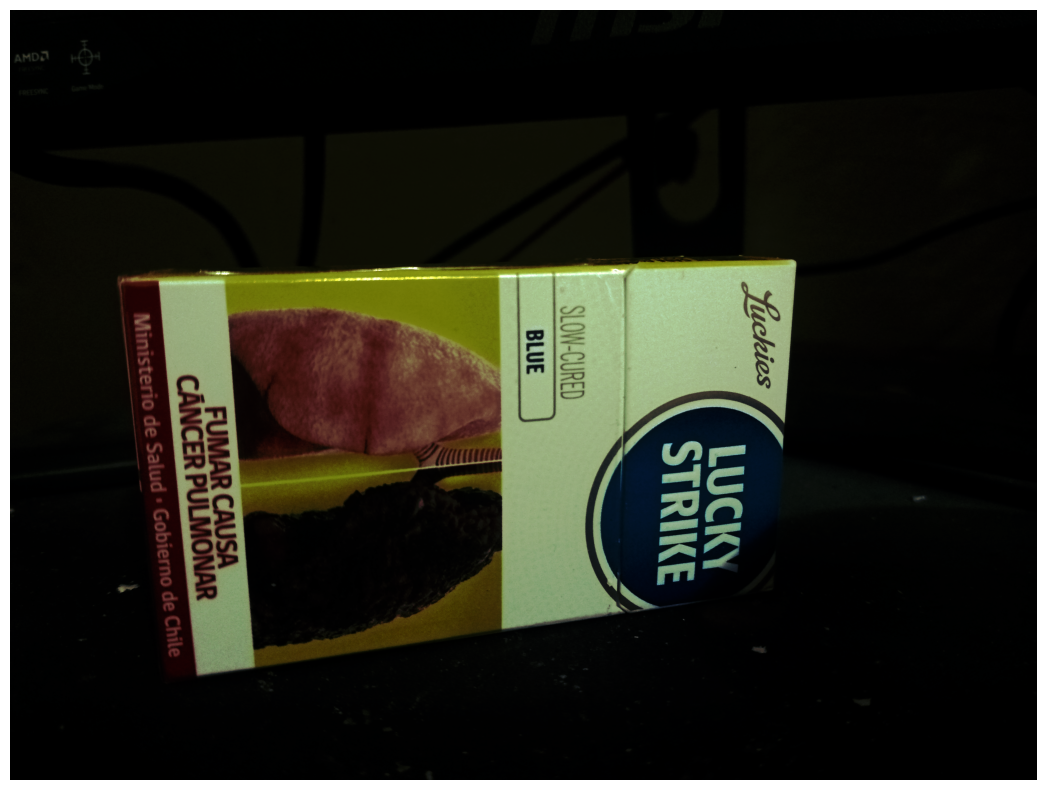

In [11]:
# Tonemap using Mantiuk's method to obtain 24-bit color image
# createTonemapMantiuk(gamma: float = ...,
#                      scale: float = ...,
#                      saturation: float = ...)
print("Tonemaping using Mantiuk's method ... ")
tonemapMantiuk = cv2.createTonemapMantiuk(.2, 0.85, .4)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = 3 * ldrMantiuk

# save the image using cv2.imwrite
cv2.imwrite("ldr-Mantiuk.jpg", ldrMantiuk * 255)

# plot the image using plt.imshow
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrMantiuk, 0, 1)[:,:,::-1]);plt.axis("off")

# High Dynamic Range (HDR) Imaging using OpenCV (C++/Python)

In this tutorial, we will learn how to create a High Dynamic Range (HDR) image using multiple images taken with different exposure settings. We will share code in both C++ and Python.

What is High Dynamic Range (HDR) imaging?
-----------------------------------------

Most digital cameras and displays capture or display color images as 24-bits matrices. There are 8-bits per color channel and the pixel values are therefore in the range 0 – 255 for each channel. In other words, a regular camera or a display has a limited dynamic range.

However, the world around us has a very large dynamic range. It can get pitch black inside a garage when the lights are turned off and it can get really bright if you are looking directly at the Sun. Even without considering those extremes, in everyday situations, 8-bits are barely enough to capture the scene. So, the camera tries to estimate the lighting and automatically sets the exposure so that the most interesting aspect of the image has good dynamic range, and the parts that are too dark and too bright are clipped off to 0 and 255 respectively.

In the Figure below, the image on the left is a normally exposed image. Notice the sky in the background is completely washed out because the camera decided to use a setting where the subject (my son) is properly photographed, but the bright sky is washed out. The image on the right is an HDR image produced by the iPhone.

[![High Dynamic Range (HDR)](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/high-dynamic-range-hdr.jpg)](https://learnopencv.com/wp-content/uploads/2017/09/high-dynamic-range-hdr.jpg)

How does an iPhone capture an HDR image? It actually takes 3 images at three different exposures. The images are taken in quick succession so there is almost no movement between the three shots. The three images are then combined to produce the HDR image. We will see the details in the next section.

The process of combining different images of the same scene acquired under different exposure settings is called **High Dynamic Range (HDR)** imaging.

How does High Dynamic Range (HDR) imaging work?
-----------------------------------------------

In this section, we will go through the steps of creating an HDR image using OpenCV.

### Step 1: Capture multiple images with different exposures

When we take a picture using a camera, we have only 8-bits per channel to represent the dynamic range ( brightness range ) of the scene. But we can take multiple images of the scene at different exposures by changing the shutter speed. Most SLR cameras have a feature called Auto Exposure Bracketing (AEB) that allows us to take multiple pictures at different exposures with just one press of a button. If you are using an iPhone, you can use this [AutoBracket HDR app](https://itunes.apple.com/us/app/autobracket-hdr/id923626339?mt=8&ign-mpt=uo%3D8) and if you are an android user you can try [A Better Camera app](https://play.google.com/store/apps/details?id=com.almalence.opencam&hl=en).

Using AEB on a camera or an auto bracketing app on the phone, we can take multiple pictures quickly one after the other so the scene does not change. When we use HDR mode in an iPhone, it takes three pictures.

1.  An **underexposed** image: This image is darker than the properly exposed image. The goal is the capture parts of the image that very bright.
2.  A **properly exposed** image: This is the regular image the camera would have taken based on the illumination it has estimated.
3.  An **overexposed** image: This image is brighter than the properly exposed image. The goal is the capture parts of the image that very dark.

However, if the dynamic range of the scene is very large, we can take more than three pictures to compose the HDR image. In this tutorial, we will use 4 images taken with exposure time 1/30, 0.25, 2.5 and 15 seconds. The thumbnails are shown below.

[![Auto Exposure Bracketed  HDR image sequence](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-image-sequence.webp)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-image-sequence.jpg)

The information about the exposure time and other settings used by an SLR camera or a Phone are usually stored in the EXIF metadata of the JPEG file. Check out this [link](https://www.howtogeek.com/289712/how-to-see-an-images-exif-data-in-windows-and-macos) to see EXIF metadata stored in a JPEG file in Windows and Mac. Alternatively, you can use my favorite command line utility for EXIF called [EXIFTOOL](https://www.sno.phy.queensu.ca/~phil/exiftool) .

Let’s start by reading in the images are assigning the exposure times

**Download Code** To easily follow along this tutorial, please download code by clicking on the button below. It's FREE!

[Download Code](javascript:void(0))

![](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/cropped-favicon-512x512-1-150x150.png)

Click here to download the source code to this post

**C++**

1

2

3

4

5

6

7

8

9

10

11

12

13

14

15

16

17

18

`void` `readImagesAndTimes(vector<Mat> &images, vector<``float``> &times)`

`{`

  `int` `numImages = 4;`

  `// List of exposure times`

  `static` `const` `float` `timesArray[] = {1/30.0f,0.25,2.5,15.0};`

  `times.assign(timesArray, timesArray + numImages);`

  `// List of image filenames`

  `static` `const` `char``* filenames[] = {``"img_0.033.jpg"``,` `"img_0.25.jpg"``,` `"img_2.5.jpg"``,` `"img_15.jpg"``};`

  `for``(``int` `i=0; i < numImages; i++)`

  `{`

    `Mat im = imread(filenames[i]);`

    `images.push_back(im);`

  `}`

`}`

**Python**

1

2

3

4

5

6

7

8

9

10

11

12

`def` `readImagesAndTimes():`

  `# List of exposure times`

  `times` `=` `np.array([` `1``/``30.0``,` `0.25``,` `2.5``,` `15.0` `], dtype``=``np.float32)`

  `# List of image filenames`

  `filenames` `=` `[``"img_0.033.jpg"``,` `"img_0.25.jpg"``,` `"img_2.5.jpg"``,` `"img_15.jpg"``]`

  `images` `=` `[]`

  `for` `filename` `in` `filenames:`

    `im` `=` `cv2.imread(filename)`

    `images.append(im)`

  `return` `images, times`

### Step 2: Align Images

Misalignment of images used in composing the HDR image can result in severe artifacts. In the Figure below, the image on the left is an HDR image composed using unaligned images and the image on the right is one using aligned images. By zooming into a part of the image, shown using red circles, we see severe ghosting artifacts in the left image.

[![Misalignment problem in HDR](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/aligned-unaligned-hdr-comparison.webp)](https://learnopencv.com/wp-content/uploads/2017/10/aligned-unaligned-hdr-comparison.jpg)

Naturally, while taking the pictures for creating an HDR image, professional photographer mount the camera on a tripod. They also use a feature called [mirror lockup](https://www.slrlounge.com/workshop/using-mirror-up-mode-mirror-lockup) to reduce additional vibrations. Even then, the images may not be perfectly aligned because there is no way to guarantee a vibration-free environment. The problem of alignment gets a lot worse when images are taken using a handheld camera or a phone.

Fortunately, OpenCV provides an easy way to align these images using `AlignMTB`. This algorithm converts all the images to median threshold bitmaps (MTB). An MTB for an image is calculated by assigning the value 1 to pixels brighter than median luminance and 0 otherwise. An MTB is invariant to the exposure time. Therefore, the MTBs can be aligned without requiring us to specify the exposure time.

MTB based alignment is performed using the following lines of code.

**C++**

1

2

3

`// Align input images`

`Ptr<AlignMTB> alignMTB = createAlignMTB();`

`alignMTB->process(images, images);`

**Python**

1

2

3

`# Align input images`

`alignMTB` `=` `cv2.createAlignMTB()`

`alignMTB.process(images, images)`

### Step 3: Recover the Camera Response Function

The response of a typical camera is not linear to scene brightness. What does that mean? Suppose, two objects are photographed by a camera and one of them is twice as bright as the other in the real world. When you measure the pixel intensities of the two objects in the photograph, the pixel values of the brighter object will not be twice that of the darker object! Without estimating the Camera Response Function (CRF), we will not be able to merge the images into one HDR image.

What does it mean to merge multiple exposure images into an HDR image?

Consider just ONE pixel at some location (x,y) of the images. If the CRF was linear, the pixel value would be directly proportional to the exposure time unless the pixel is too dark ( i.e. nearly 0 ) or too bright ( i.e. nearly 255) in a particular image. We can filter out these bad pixels ( too dark or too bright ), and estimate the brightness at a pixel by dividing the pixel value by the exposure time and then averaging this brightness value across all images where the pixel is not bad ( too dark or too bright ). We can do this for all pixels and obtain a single image where all pixels are obtained by averaging “good” pixels.

But the CRF is not linear and we need to make the image intensities linear before we can merge/average them by first estimating the CRF.

The good news is that the CRF can be estimated from the images if we know the exposure times for each image. Like many problems in computer vision, the problem of finding the CRF is set up as an optimization problem where the goal is to minimize an objective function consisting of a data term and a smoothness term. These problems usually reduce to a linear least squares problem which are solved using Singular Value Decomposition (SVD) that is part of all linear algebra packages. The details of the CRF recovery algorithm are in the paper titled [Recovering High Dynamic Range Radiance Maps from Photographs](http://www.pauldebevec.com/Research/HDR/debevec-siggraph97.pdf).

Finding the CRF is done using just two lines of code in OpenCV using `CalibrateDebevec` or `CalibrateRobertson`. In this tutorial we will use `CalibrateDebevec`

**C++**

1

2

3

4

`// Obtain Camera Response Function (CRF)`

`Mat responseDebevec;`

`Ptr<CalibrateDebevec> calibrateDebevec = createCalibrateDebevec();`

`calibrateDebevec->process(images, responseDebevec, times);`

**Python**

1

2

3

`# Obtain Camera Response Function (CRF)`

`calibrateDebevec` `=` `cv2.createCalibrateDebevec()`

`responseDebevec` `=` `calibrateDebevec.process(images, times)`

The figure below shows the CRF recovered using the images for the red, green and blue channels.

[![Camera Response Function](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/camera-response-function.webp)](https://learnopencv.com/wp-content/uploads/2017/10/camera-response-function.jpg)

### Step 4: Merge Images

Once the CRF has been estimated, we can merge the exposure images into one HDR image using `MergeDebevec`. The C++ and Python code is shown below.

**C++**

1

2

3

4

5

6

`// Merge images into an HDR linear image`

`Mat hdrDebevec;`

`Ptr<MergeDebevec> mergeDebevec = createMergeDebevec();`

`mergeDebevec->process(images, hdrDebevec, times, responseDebevec);`

`// Save HDR image.`

`imwrite(``"hdrDebevec.hdr"``, hdrDebevec);`

**Python**

1

2

3

4

5

`# Merge images into an HDR linear image`

`mergeDebevec` `=` `cv2.createMergeDebevec()`

`hdrDebevec` `=` `mergeDebevec.process(images, times, responseDebevec)`

`# Save HDR image.`

`cv2.imwrite(``"hdrDebevec.hdr"``, hdrDebevec)`

The HDR image saved above can be loaded in Photoshop and tonemapped. An example is shown below.

[![HDR Photoshop tone mapping](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-Photoshop-Tonemapping-1024x770.webp)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-Photoshop-Tonemapping.jpg)

HDR Photoshop tone mapping

### Step 5: Tone mapping

Now we have merged our exposure images into one HDR image. Can you guess the minimum and maximum pixel values for this image? The minimum value is obviously 0 for a pitch black condition. What is the theoretical maximum value? Infinite! In practice, the maximum value is different for different situations. If the scene contains a very bright light source, we will see a very large maximum value.

Even though we have recovered the relative brightness information using multiple images, we now have the challenge of saving this information as a 24-bit image for display purposes.

The process of converting a High Dynamic Range (HDR) image to an 8-bit per channel image while preserving as much detail as possible is called **Tone mapping**.

There are several tone mapping algorithms. OpenCV implements four of them. The thing to keep in mind is that there is no right way to do tone mapping. Usually, we want to see more detail in the tonemapped image than in any one of the exposure images. Sometimes the goal of tone mapping is to produce realistic images and often times the goal is to produce surreal images. The algorithms implemented in OpenCV tend to produce realistic and therefore less dramatic results.

Let’s look at the various options. Some of the common parameters of the different tone mapping algorithms are listed below.

1.  **gamma** : This parameter compresses the dynamic range by applying a gamma correction. When gamma is equal to 1, no correction is applied. A gamma of less than 1 darkens the image, while a gamma greater than 1 brightens the image.
2.  **saturation** : This parameter is used to increase or decrease the amount of saturation. When saturation is high, the colors are richer and more intense. Saturation value closer to zero, makes the colors fade away to grayscale.
3.  **contrast** : Controls the contrast ( i.e. log (maxPixelValue/minPixelValue) ) of the output image.

Let us explore the four tone mapping algorithms available in OpenCV.

#### Drago Tonemap

The parameters for Drago Tonemap are shown below

1

2

3

4

5

6

`createTonemapDrago`

`(`

`float`  `gamma = 1.0f,`

`float`  `saturation = 1.0f,`

`float`  `bias = 0.85f`

`)`

Here, **bias** is the value for bias function in \[0, 1\] range. Values from 0.7 to 0.9 usually give the best results. The default value is 0.85. For more technical details, please see this [paper](http://resources.mpi-inf.mpg.de/tmo/logmap/logmap.pdf).

The C++ and Python code are shown below. The parameters were obtained by trial and error. The final output is multiplied by 3 just because it gave the most pleasing results.

**C++**

1

2

3

4

5

6

`// Tonemap using Drago's method to obtain 24-bit color image`

`Mat ldrDrago;`

`Ptr<TonemapDrago> tonemapDrago = createTonemapDrago(1.0, 0.7);`

`tonemapDrago->process(hdrDebevec, ldrDrago);`

`ldrDrago = 3 * ldrDrago;`

`imwrite(``"ldr-Drago.jpg"``, ldrDrago * 255);`

**Python**

1

2

3

4

5

`# Tonemap using Drago's method to obtain 24-bit color image`

`tonemapDrago` `=` `cv2.createTonemapDrago(``1.0``,` `0.7``)`

`ldrDrago` `=` `tonemapDrago.process(hdrDebevec)`

`ldrDrago` `=` `3` `*` `ldrDrago`

`cv2.imwrite(``"ldr-Drago.jpg"``, ldrDrago` `*` `255``)`

**Result**

[![HDR tone mapping using Drago's algorithm](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-Drago-1024x770.jpg)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-Drago.jpg)

HDR tone mapping using Drago’s algorithm

#### Durand Tonemap

The parameters for Durand Tonemap are shown below.

1

2

3

4

5

6

7

8

`createTonemapDurand`

`(`

  `float`  `gamma = 1.0f,`

  `float`  `contrast = 4.0f,`

  `float`  `saturation = 1.0f,`

  `float`  `sigma_space = 2.0f,`

  `float`  `sigma_color = 2.0f`

`);`


The algorithm is based on the decomposition of the image into a base layer and a detail layer. The base layer is obtained using an edge-preserving filter called the bilateral filter. **sigma\_space** and **sigma\_color** are the parameters of the bilateral filter that control the amount of smoothing in the spatial and color domains respectively.

For more details, check out this [paper](https://people.csail.mit.edu/fredo/PUBLI/Siggraph2002/DurandBilateral.pdf).

**C++**

1

2

3

4

5

6

`// Tonemap using Durand's method obtain 24-bit color image`

`Mat ldrDurand;`

`Ptr<TonemapDurand> tonemapDurand = createTonemapDurand(1.5,4,1.0,1,1);`

`tonemapDurand->process(hdrDebevec, ldrDurand);`

`ldrDurand = 3 * ldrDurand;`

`imwrite(``"ldr-Durand.jpg"``, ldrDurand * 255);`

**Python**

1

2

3

4

5

`# Tonemap using Durand's method obtain 24-bit color image`

`tonemapDurand` `=` `cv2.createTonemapDurand(``1.5``,``4``,``1.0``,``1``,``1``)`

`ldrDurand` `=` `tonemapDurand.process(hdrDebevec)`

`ldrDurand` `=` `3` `*` `ldrDurand`

`cv2.imwrite(``"ldr-Durand.jpg"``, ldrDurand` `*` `255``)`

**Result**

[![HDR tone mapping using Durand's algorithm](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-Durand-1024x770.jpg)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-Durand.jpg)

HDR tone mapping using Durand’s algorithm

#### Reinhard Tonemap

1

2

3

4

5

6

7

`createTonemapReinhard`

`(`

`float`  `gamma = 1.0f,`

`float`  `intensity = 0.0f,`

`float`  `light_adapt = 1.0f,`

`float`  `color_adapt = 0.0f`

`)`

The parameter **intensity** should be in the \[-8, 8\] range. Greater intensity value produces brighter results. **light\_adapt** controls the light adaptation and is in the \[0, 1\] range. A value of 1 indicates adaptation based only on pixel value and a value of 0 indicates global adaptation. An in-between value can be used for a weighted combination of the two. The parameter **color\_adapt** controls chromatic adaptation and is in the \[0, 1\] range. The channels are treated independently if the value is set to 1 and the adaptation level is the same for every channel if the value is set to 0. An in-between value can be used for a weighted combination of the two.

For more details, check out this [paper](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.106.8100&rep=rep1&type=pdf).

**C++**

1

2

3

4

5

`// Tonemap using Reinhard's method to obtain 24-bit color image`

`Mat ldrReinhard;`

`Ptr<TonemapReinhard> tonemapReinhard = createTonemapReinhard(1.5, 0,0,0);`

`tonemapReinhard->process(hdrDebevec, ldrReinhard);`

`imwrite(``"ldr-Reinhard.jpg"``, ldrReinhard * 255);`

**Python**

1

2

3

4

`# Tonemap using Reinhard's method to obtain 24-bit color image`

`tonemapReinhard` `=` `cv2.createTonemapReinhard(``1.5``,` `0``,``0``,``0``)`

`ldrReinhard` `=` `tonemapReinhard.process(hdrDebevec)`

`cv2.imwrite(``"ldr-Reinhard.jpg"``, ldrReinhard` `*` `255``)`


**Result**

[![HDR tone mapping using Reinhard's algorithm](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-Reinhard-1024x770.jpg)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-Reinhard.jpg)

HDR tone mapping using Reinhard’s algorithm

#### Mantiuk Tonemap

1

2

3

4

5

6

`createTonemapMantiuk`

`(`

`float`  `gamma = 1.0f,`

`float`  `scale = 0.7f,`

`float`  `saturation = 1.0f`

`)`

The parameter **scale** is the contrast scale factor. Values from 0.6 to 0.9 produce best results.

For more details, check out this [paper](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.60.4077&rep=rep1&type=pdf)

**C++**

1

2

3

4

5

6

`// Tonemap using Mantiuk's method to obtain 24-bit color image`

`Mat ldrMantiuk;`

`Ptr<TonemapMantiuk> tonemapMantiuk = createTonemapMantiuk(2.2,0.85, 1.2);`

`tonemapMantiuk->process(hdrDebevec, ldrMantiuk);`

`ldrMantiuk = 3 * ldrMantiuk;`

`imwrite(``"ldr-Mantiuk.jpg"``, ldrMantiuk * 255);`

**Python**

1

2

3

4

5

`# Tonemap using Mantiuk's method to obtain 24-bit color image`

`tonemapMantiuk = cv2.createTonemapMantiuk(2.2,0.85, 1.2)`

`ldrMantiuk = tonemapMantiuk.process(hdrDebevec)`

`ldrMantiuk = 3 * ldrMantiuk`

`cv2.imwrite("ldr-Mantiuk.jpg", ldrMantiuk * 255)`

**Result**

[![HDR tone mapping using Mantiuk's algorithm](High%20Dynamic%20Range%20(HDR)%20Imaging%20using%20OpenCV%20(C++_Python)%20_files/hdr-Mantiuk-1024x770.jpg)](https://learnopencv.com/wp-content/uploads/2017/10/hdr-Mantiuk.jpg)

HDR Tone mapping using Mantiuk’s algorithm

**Image Credits**
The four exposure images used in this post are licensed under [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/) and were downloaded from [Wikipedia’s HDR page](https://en.wikipedia.org/wiki/High-dynamic-range_imaging). They were photographed by Kevin McCoy.

